# 🛢️ Análisis Exploratorio de Datos — Propiedades de Hidrocarburos

**Proyecto:** Predicción de calidad de crudos mediante Machine Learning  
**Dataset:** U.S. Department of Energy — Bureau of Mines Crude Oil Analysis Database  
**Autor:** Tomás Malafiej — Licenciatura en Ciencia de Datos, UCASAL

---

## Contexto

El **Bureau of Mines** de Estados Unidos analizó sistemáticamente más de 9.000 muestras de crudo entre 1920 y 1983, registrando propiedades físico-químicas bajo métodos estandarizados ASTM. Esta base de datos, hoy disponible públicamente a través del DOE, representa uno de los registros históricos más completos de caracterización de hidrocarburos.

Las propiedades medidas son exactamente las que empresas de inspección como **AmSpec** determinan en sus laboratorios para certificar la calidad del crudo antes de su comercialización.

## Objetivos de este notebook

1. Cargar y limpiar el dataset original
2. Seleccionar las variables físico-químicas relevantes
3. Detectar y tratar valores atípicos
4. Crear la variable objetivo de clasificación
5. Generar visualizaciones que expliquen el comportamiento del crudo
6. Extraer conclusiones para guiar el modelado

## 1. Importaciones y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Cargar dataset original
df_raw = pd.read_excel('../data/Summary of Analyses.xls')

print(f'Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')

Dataset cargado: 9,076 filas × 54 columnas


## 2. Selección de variables y limpieza

De las 54 columnas disponibles, seleccionamos las **propiedades físico-químicas** medidas directamente en laboratorio bajo normas ASTM. Descartamos columnas administrativas, geológicas y de identificación que no aportan al análisis predictivo.

| Variable | Descripción | Unidad |
|---|---|---|
| `API_CRUDE` | Gravedad API del crudo | °API |
| `SRC` | Contenido de azufre | % en peso |
| `CRN` | Contenido de nitrógeno | % en peso |
| `SU100` | Viscosidad Saybolt a 100°F | SUS |
| `POUR_POINT` | Punto de fluidez | °F |
| `CAR_CR_WT` | Residuo de carbono | % en peso |
| `LT_GAS_VOL` | Volumen % gasolina ligera | % vol |
| `GAS_NP_VOL` | Volumen % gasolina y nafta | % vol |
| `RESDUM_VOL` | Volumen % residuo de destilación | % vol |

> **Nota sobre `SGRAV_CRUD`:** Esta columna representa la gravedad específica del crudo y debería correlacionar fuertemente con `API_CRUDE` (fórmula: °API = 141.5/SG − 131.5). Sin embargo, el dataset contiene valores codificados para gravedades >0.999 usando caracteres alfanuméricos, lo que generó errores de parsing. Por eso se excluye y se utiliza `API_CRUDE` como medida de densidad.

In [2]:
# Seleccionar columnas relevantes
columnas_clave = [
    'STCTNAME',    # Estado/País de origen
    'FIELD_NAME',  # Nombre del campo petrolero
    'API_CRUDE',   # Gravedad API
    'SRC',         # Azufre (%)
    'CRN',         # Nitrógeno (%)
    'SU100',       # Viscosidad a 100°F
    'POUR_POINT',  # Punto de fluidez
    'CAR_CR_WT',   # Residuo de carbono
    'LT_GAS_VOL',  # Vol. gasolina ligera
    'GAS_NP_VOL',  # Vol. gasolina y nafta
    'RESDUM_VOL',  # Vol. residuo
]

df = df_raw[columnas_clave].copy()

print('Valores nulos por columna antes de limpieza:')
print(df.isnull().sum())
print(f'\nTotal filas antes: {len(df):,}')

# Eliminar filas con nulos
df = df.dropna().copy()
print(f'Total filas después de eliminar nulos: {len(df):,}')

Valores nulos por columna antes de limpieza:
STCTNAME      3
FIELD_NAME    0
API_CRUDE     2
SRC           2
CRN           2
SU100         3
POUR_POINT    3
CAR_CR_WT     0
LT_GAS_VOL    0
GAS_NP_VOL    0
RESDUM_VOL    0
dtype: int64

Total filas antes: 9,076
Total filas después de eliminar nulos: 9,071


## 3. Detección y tratamiento de outliers

Antes de analizar, identificamos valores físicamente imposibles o extremos que podrían distorsionar las visualizaciones y los modelos.

In [3]:
print('Estadísticas descriptivas — variables numéricas:')
print(df.describe().round(2))

# Detectar outliers por variable
print('\n--- Detección de valores sospechosos ---')
print(f'API_CRUDE > 70 (físicamente raro): {(df["API_CRUDE"] > 70).sum()} registros')
print(f'API_CRUDE = 0 (sin medición): {(df["API_CRUDE"] == 0).sum()} registros')
print(f'SRC > 10% (azufre extremo): {(df["SRC"] > 10).sum()} registros')
print(f'SU100 > 2000 SUS (viscosidad extrema): {(df["SU100"] > 2000).sum()} registros')

# Aplicar filtros físicamente justificados
df = df[
    (df['API_CRUDE'] > 0) &      # API debe ser positivo
    (df['API_CRUDE'] <= 70) &    # API > 70 es condensado, no crudo típico
    (df['SRC'] <= 10) &          # Azufre > 10% es físicamente raro
    (df['SU100'] <= 2000)        # Viscosidad > 2000 SUS son casos extremos
].copy()

print(f'\nDataset final tras limpieza: {len(df):,} muestras')

Estadísticas descriptivas — variables numéricas:
       API_CRUDE      SRC      CRN     SU100  POUR_POINT  CAR_CR_WT  \
count    9071.00  9071.00  9071.00   9071.00     9071.00    9071.00   
mean       35.84     0.60     0.05    200.41       11.41       2.06   
std         8.88     0.89     0.10    809.37       17.56       2.30   
min         0.00     0.00     0.00      0.00       -1.00       0.00   
25%        31.30     0.12     0.00     37.00        0.00       0.50   
50%        37.00     0.23     0.00     43.00        5.00       1.40   
75%        40.90     0.61     0.07     58.00       10.00       2.70   
max        72.40    13.08     0.96  21794.00      230.00      19.30   

       LT_GAS_VOL  GAS_NP_VOL  RESDUM_VOL  
count     9071.00     9071.00     9071.00  
mean         7.92       28.51       24.75  
std          6.49       14.96       12.55  
min          0.00        0.00        0.00  
25%          3.40       19.80       17.40  
50%          7.50       29.30       23.20  
75%

## 4. Creación de variables objetivo

Definimos dos clasificaciones estándar de la industria petrolera:

**Tipo de crudo por gravedad API** (clasificación API estándar):
- **Liviano:** API > 31.1°
- **Mediano:** 22.3° ≤ API ≤ 31.1°
- **Pesado:** 10° ≤ API < 22.3°
- **Extra pesado:** API < 10° *(excluido por insuficiente representación: 14 muestras)*

**Clasificación dulce/agrio por contenido de azufre** (umbral industria):
- **Dulce (sweet):** azufre < 0.5% en peso
- **Agrio (sour):** azufre ≥ 0.5% en peso

In [4]:
# Clasificación por tipo de crudo
def clasificar_tipo(api):
    if api > 31.1:
        return 'Liviano'
    elif api >= 22.3:
        return 'Mediano'
    elif api >= 10:
        return 'Pesado'
    else:
        return 'Extra pesado'

df['TIPO_CRUDO'] = df['API_CRUDE'].apply(clasificar_tipo)

# Clasificación dulce/agrio
df['CLASE_AZUFRE'] = df['SRC'].apply(
    lambda x: 'Dulce (sweet) < 0.5%S' if x < 0.5 else 'Agrio (sour) ≥ 0.5%S'
)

# Excluir Extra pesado por representación insuficiente
n_extra = (df['TIPO_CRUDO'] == 'Extra pesado').sum()
print(f'Muestras "Extra pesado" excluidas del análisis: {n_extra}')
print('Motivo: insuficiente representación estadística para modelado confiable.')

df_modelo = df[df['TIPO_CRUDO'] != 'Extra pesado'].copy()

print(f'\nDistribución final de tipos de crudo:')
print(df_modelo['TIPO_CRUDO'].value_counts())
print(f'\nClasificación dulce/agrio:')
print(df_modelo['CLASE_AZUFRE'].value_counts())

# Guardar dataset limpio
df_modelo.to_csv('../data/crude_oil_clean.csv', index=False)
print(f'\nDataset limpio guardado: {len(df_modelo):,} muestras, {df_modelo.shape[1]} columnas')

Muestras "Extra pesado" excluidas del análisis: 5
Motivo: insuficiente representación estadística para modelado confiable.

Distribución final de tipos de crudo:
TIPO_CRUDO
Liviano    6805
Mediano    1472
Pesado      565
Name: count, dtype: int64

Clasificación dulce/agrio:
CLASE_AZUFRE
Dulce (sweet) < 0.5%S    6405
Agrio (sour) ≥ 0.5%S     2437
Name: count, dtype: int64

Dataset limpio guardado: 8,842 muestras, 13 columnas


## 5. Análisis exploratorio visual

### 5.1 Distribución de propiedades por tipo de crudo

Analizamos cómo varían la gravedad API y el contenido de azufre entre los distintos tipos de crudo, y exploramos la relación entre ambas variables.

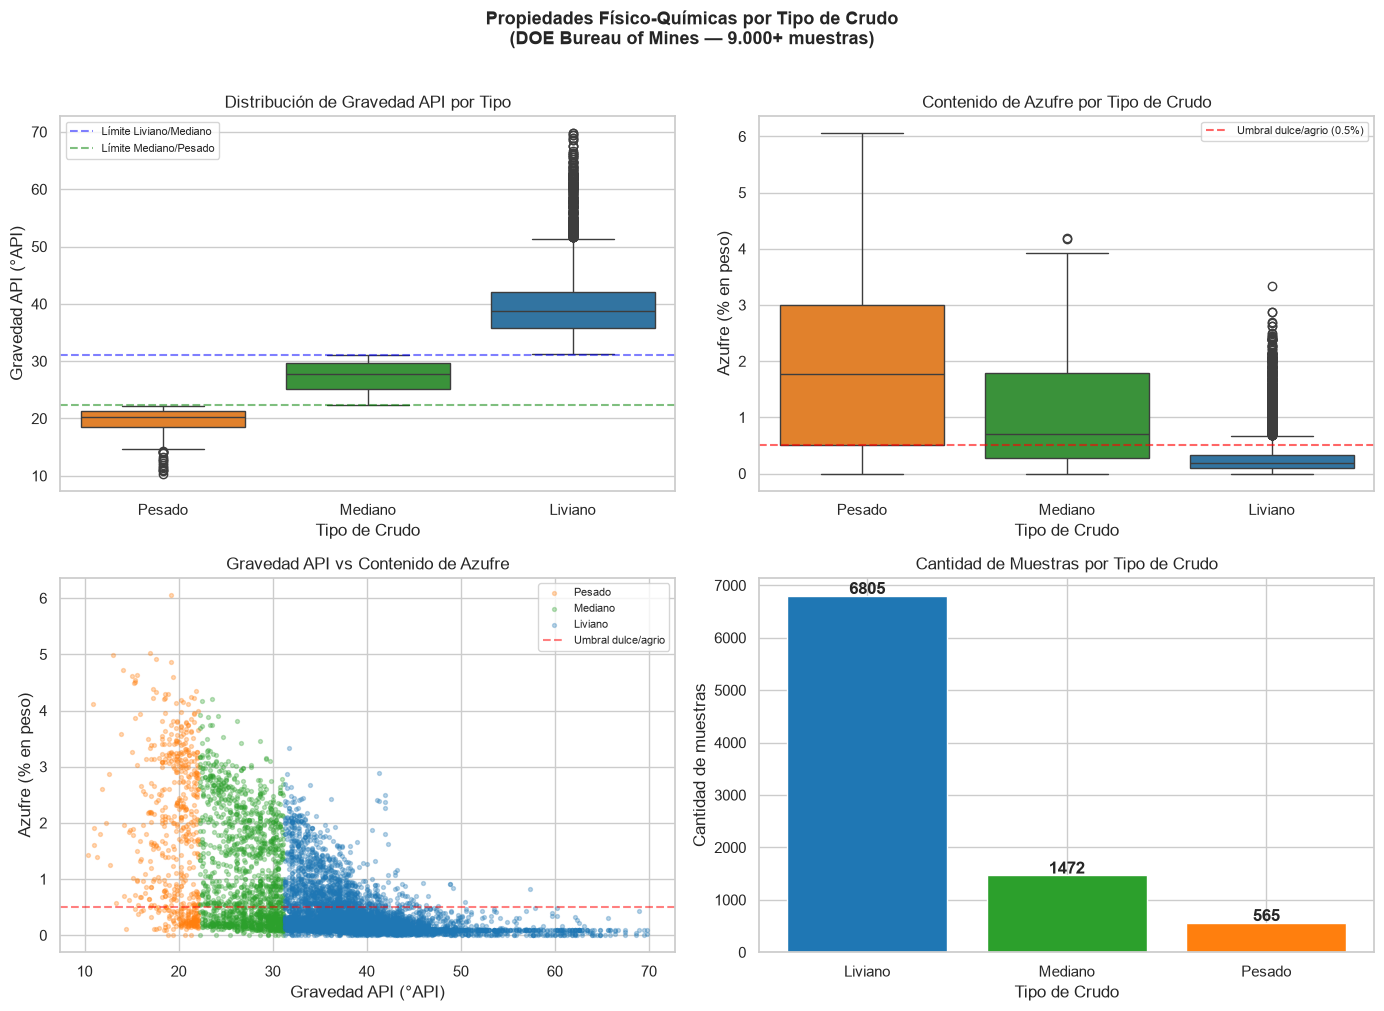

Gráfico guardado.


In [5]:
orden = ['Pesado', 'Mediano', 'Liviano']
paleta = {'Liviano': '#1f77b4', 'Mediano': '#2ca02c', 'Pesado': '#ff7f0e'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Propiedades Físico-Químicas por Tipo de Crudo\n(DOE Bureau of Mines — 9.000+ muestras)',
    fontsize=13, fontweight='bold', y=1.01
)

# 1. Distribución API por tipo
sns.boxplot(
    data=df_modelo, x='TIPO_CRUDO', y='API_CRUDE',
    order=orden, palette=paleta, ax=axes[0, 0]
)
axes[0, 0].set_title('Distribución de Gravedad API por Tipo')
axes[0, 0].set_xlabel('Tipo de Crudo')
axes[0, 0].set_ylabel('Gravedad API (°API)')
axes[0, 0].axhline(y=31.1, color='blue', linestyle='--', alpha=0.5, label='Límite Liviano/Mediano')
axes[0, 0].axhline(y=22.3, color='green', linestyle='--', alpha=0.5, label='Límite Mediano/Pesado')
axes[0, 0].legend(fontsize=8)

# 2. Contenido de azufre por tipo
sns.boxplot(
    data=df_modelo, x='TIPO_CRUDO', y='SRC',
    order=orden, palette=paleta, ax=axes[0, 1]
)
axes[0, 1].set_title('Contenido de Azufre por Tipo de Crudo')
axes[0, 1].set_xlabel('Tipo de Crudo')
axes[0, 1].set_ylabel('Azufre (% en peso)')
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='Umbral dulce/agrio (0.5%)')
axes[0, 1].legend(fontsize=8)

# 3. Scatter API vs Azufre
for tipo in orden:
    subset = df_modelo[df_modelo['TIPO_CRUDO'] == tipo]
    axes[1, 0].scatter(
        subset['API_CRUDE'], subset['SRC'],
        c=paleta[tipo], alpha=0.3, s=8, label=tipo
    )
axes[1, 0].set_title('Gravedad API vs Contenido de Azufre')
axes[1, 0].set_xlabel('Gravedad API (°API)')
axes[1, 0].set_ylabel('Azufre (% en peso)')
axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Umbral dulce/agrio')
axes[1, 0].legend(fontsize=8)

# 4. Cantidad de muestras por tipo
conteo = df_modelo['TIPO_CRUDO'].value_counts().reindex(orden[::-1])
bars = axes[1, 1].bar(
    conteo.index, conteo.values,
    color=[paleta[t] for t in conteo.index],
    edgecolor='white'
)
axes[1, 1].set_title('Cantidad de Muestras por Tipo de Crudo')
axes[1, 1].set_xlabel('Tipo de Crudo')
axes[1, 1].set_ylabel('Cantidad de muestras')
for bar, val in zip(bars, conteo.values):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 30, str(val), ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../data/eda_propiedades_crudo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

**Interpretación:**

- Los rangos de API son bien separados entre tipos, lo que confirma que la clasificación es consistente con la norma API.
- Los crudos **pesados tienden a tener mayor contenido de azufre** y más variabilidad, siendo más difíciles de clasificar como dulces o agrios.
- El scatter muestra una **tendencia inversa clara entre API y azufre**: a mayor gravedad API (crudo más liviano), menor contenido de azufre. Esta relación es clave para el modelo predictivo.

### 5.2 Correlación entre propiedades físico-químicas

El heatmap de correlaciones revela las relaciones entre todas las variables medidas en laboratorio.

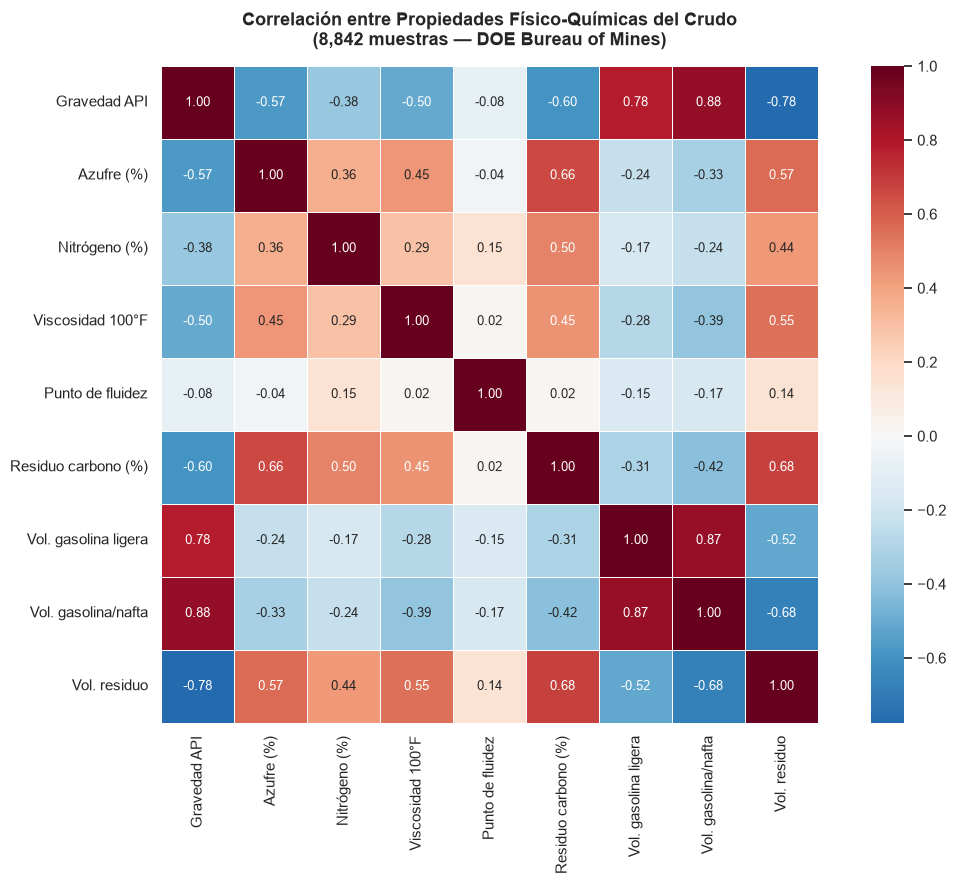

Heatmap guardado.


In [6]:
columnas_num = [
    'API_CRUDE', 'SRC', 'CRN', 'SU100',
    'POUR_POINT', 'CAR_CR_WT', 'LT_GAS_VOL',
    'GAS_NP_VOL', 'RESDUM_VOL'
]

nombres = {
    'API_CRUDE':   'Gravedad API',
    'SRC':         'Azufre (%)',
    'CRN':         'Nitrógeno (%)',
    'SU100':       'Viscosidad 100°F',
    'POUR_POINT':  'Punto de fluidez',
    'CAR_CR_WT':   'Residuo carbono (%)',
    'LT_GAS_VOL':  'Vol. gasolina ligera',
    'GAS_NP_VOL':  'Vol. gasolina/nafta',
    'RESDUM_VOL':  'Vol. residuo'
}

df_corr = df_modelo[columnas_num].rename(columns=nombres)
matriz = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    matriz,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    square=True, linewidths=0.5,
    ax=ax, annot_kws={'size': 9}
)
ax.set_title(
    'Correlación entre Propiedades Físico-Químicas del Crudo\n'
    f'({len(df_modelo):,} muestras — DOE Bureau of Mines)',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('../data/heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap guardado.')

**Correlaciones destacadas:**

| Par de variables | Correlación | Interpretación |
|---|---|---|
| API ↔ Vol. gasolina/nafta | +0.88 | Crudos livianos producen más nafta en destilación |
| API ↔ Vol. residuo | -0.77 | Crudos pesados generan más residuo |
| API ↔ Azufre | -0.56 | Los crudos livianos tienden a ser más dulces |
| Residuo carbono ↔ Azufre | +0.64 | Los crudos sucios tienen más azufre y más residuo |
| API ↔ Viscosidad | -0.50 | Los crudos pesados son más viscosos |

Estas correlaciones son físicamente coherentes y confirman la calidad del dataset.

### 5.3 Origen geográfico y perfil de azufre

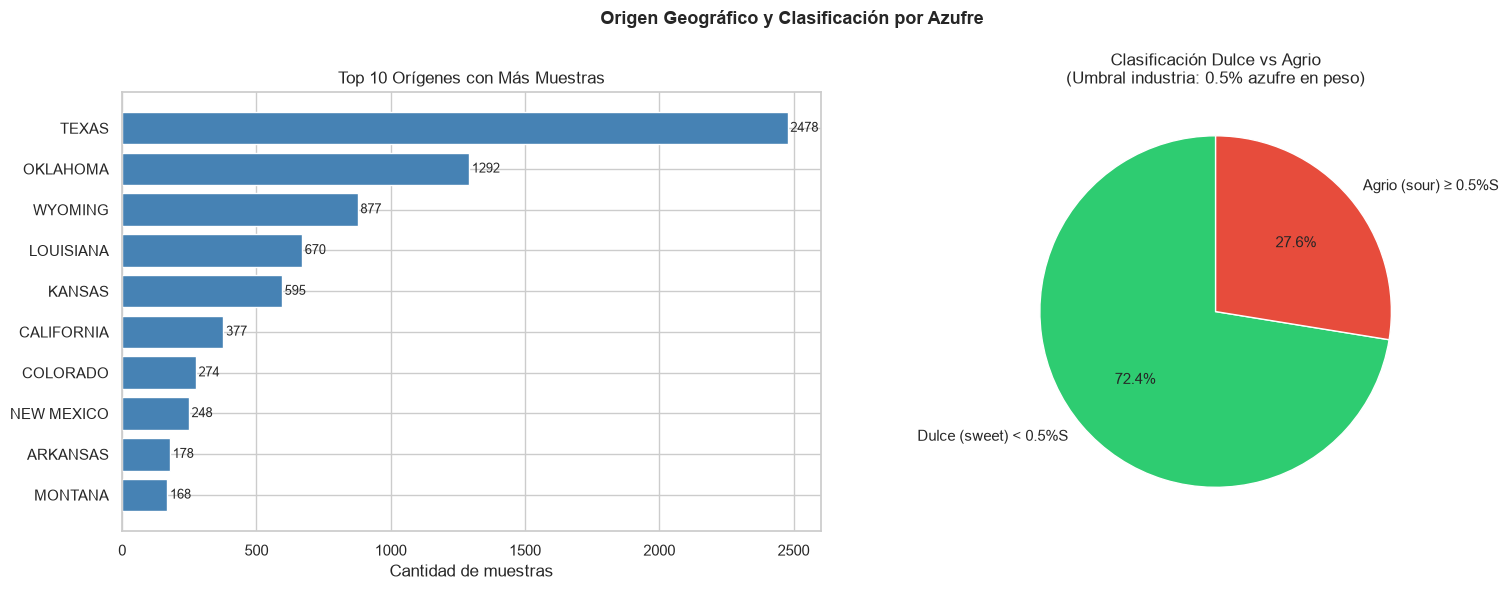

Gráfico guardado.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Origen Geográfico y Clasificación por Azufre', fontsize=13, fontweight='bold')

# Top 10 orígenes
top = df_modelo['STCTNAME'].value_counts().head(10)
axes[0].barh(top.index[::-1], top.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Orígenes con Más Muestras')
axes[0].set_xlabel('Cantidad de muestras')
for i, v in enumerate(top.values[::-1]):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# Dulce vs agrio
conteo_s = df_modelo['CLASE_AZUFRE'].value_counts()
axes[1].pie(
    conteo_s.values,
    labels=conteo_s.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Clasificación Dulce vs Agrio\n(Umbral industria: 0.5% azufre en peso)')

plt.tight_layout()
plt.savefig('../data/eda_geografia_azufre.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

**Interpretación:**

- El dataset está dominado por crudos de **Texas y Oklahoma**, los estados históricamente más productivos de EE.UU.
- El **70.9% de las muestras son crudos dulces** (azufre < 0.5%), lo que representa un desbalance de clases que será considerado en el modelado mediante técnicas de ponderación.

## 6. Conclusiones del análisis exploratorio

### Hallazgos principales

1. **La gravedad API es el predictor más informativo**: determina directamente el tipo de crudo y correlaciona fuertemente con casi todas las demás propiedades.

2. **Relación inversa API–Azufre confirmada**: los crudos más livianos tienden a ser más dulces. Esta relación permite predecir el perfil de azufre a partir de otras propiedades medibles.

3. **Variables de destilación son altamente informativas**: los volúmenes de gasolina/nafta y residuo correlacionan fuertemente con la gravedad API (r = 0.88 y -0.77 respectivamente), lo que las convierte en features valiosas para el modelado.

4. **El punto de fluidez es el predictor más débil**: correlaciona muy poco con las demás variables, lo que sugiere que depende de factores composicionales específicos no capturados por las otras mediciones.

5. **Desbalance de clases**: 70.9% dulce vs 29.1% agrio. Los modelos deberán compensar este desbalance mediante `class_weight='balanced'` o ponderación de muestras.

### Variables seleccionadas para modelado

```python
features = [
    'API_CRUDE',   # Gravedad API — predictor principal
    'SU100',       # Viscosidad — diferencia pesados de livianos
    'CRN',         # Nitrógeno — indicador de origen geoquímico
    'POUR_POINT',  # Punto de fluidez — propiedad de transporte
    'CAR_CR_WT',   # Residuo carbono — indicador de calidad
    'LT_GAS_VOL',  # Vol. gasolina ligera — rendimiento de destilación
    'GAS_NP_VOL',  # Vol. gasolina/nafta — rendimiento de destilación
    'RESDUM_VOL',  # Vol. residuo — indicador de pesadez
]
# Nota: SRC (azufre) se excluye cuando es la variable objetivo
```

---
*Siguiente paso: [02_modelos_ml.ipynb](02_modelos_ml.ipynb) — Entrenamiento y comparación de modelos*